# Wafer Anomaly Detection with PatchCore + EfficientNet-B1 (50k Train Normals)

This notebook trains a PatchCore-style anomaly detector on **50,000 normal wafers** and tests on:
- **5,000 normal** wafers
- **250 defect** wafers

Pipeline:
1. Load and clean WM-811K style wafer data
2. Convert wafer maps to 3-channel tensors
3. Extract multi-scale patch embeddings from a pretrained CNN
4. Build PatchCore memory bank from train-normal patches
5. Score test images by nearest-neighbor patch distance
6. Evaluate with ROC-AUC, confusion matrix, and classification report

In [40]:
# Core imports
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Using device:', DEVICE)

Using device: cuda


In [41]:
# Configuration
DATA_PATH = '../data/raw/LSWMD.pkl'
IMAGE_SIZE = 240
BATCH_SIZE = 128

TRAIN_NORMAL_N = 20000
TEST_NORMAL_N = 5000
TEST_DEFECT_N = 250

# PatchCore memory/scoring settings
MEMORY_BANK_MAX_PATCHES = 340000
SCORE_CHUNK = 1024
PATCHCORE_NN_K = 3
TOPK_PATCH_RATIO = 0.03
EFFNET_MID_FEATURE_IDX = 3
EFFNET_DEEP_FEATURE_IDX = 8
PATCH_EMBED_DIM = 256

# Fixed threshold (no tune split)
THRESHOLD_TRAIN_PERCENTILE = 99.0

# Artifact output
ARTIFACT_DIR = '../artifacts/x64/patchcore_efficientnet_b1_50k'
MODEL_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'patchcore_efficientnet_b1_model.pt')
METRICS_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(
    f'batch={BATCH_SIZE}, bbank_max={MEMORY_BANK_MAX_PATCHES}, '
    f'chunk={SCORE_CHUNK}, amp={USE_CUDA}, topk_ratio={TOPK_PATCH_RATIO}, '
    f'nn_k={PATCHCORE_NN_K}, eff_mid={EFFNET_MID_FEATURE_IDX}, '
    f'eff_deep={EFFNET_DEEP_FEATURE_IDX}, emb_dim={PATCH_EMBED_DIM}'
)
print(f'No tune split: threshold percentile on train-normal = {THRESHOLD_TRAIN_PERCENTILE}')
print('Artifacts will be saved to:', ARTIFACT_DIR)

batch=128, bbank_max=340000, chunk=1024, amp=True, topk_ratio=0.03, nn_k=3, eff_mid=3, eff_deep=8, emb_dim=256
No tune split: threshold percentile on train-normal = 99.0
Artifacts will be saved to: ../artifacts/x64/patchcore_efficientnet_b1_50k


In [42]:
# Load and clean labels
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(value):
    if value is None:
        return 'unknown'
    if isinstance(value, float) and np.isnan(value):
        return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        if len(arr) == 0:
            return 'unknown'
        return str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print('Labeled shape:', df.shape)
print('Normal wafers:', len(normal_df))
print('Defect wafers:', len(defect_df))

Raw shape: (811457, 6)
Labeled shape: (172950, 8)
Normal wafers: 147431
Defect wafers: 25519


In [43]:
# Enforce requested split sizes (no tune split)
required_normals = TRAIN_NORMAL_N + TEST_NORMAL_N
required_defects = TEST_DEFECT_N

if len(normal_df) < required_normals:
    raise ValueError(f'Not enough normal wafers: need {required_normals}, found {len(normal_df)}')
if len(defect_df) < required_defects:
    raise ValueError(f'Not enough defect wafers: need {required_defects}, found {len(defect_df)}')

rng = np.random.default_rng(SEED)
normal_idx = rng.permutation(len(normal_df))
defect_idx = rng.permutation(len(defect_df))

normal_df_shuf = normal_df.iloc[normal_idx].reset_index(drop=True)
defect_df_shuf = defect_df.iloc[defect_idx].reset_index(drop=True)

n0 = 0
n1 = TRAIN_NORMAL_N
n2 = TRAIN_NORMAL_N + TEST_NORMAL_N

train_normal_df = normal_df_shuf.iloc[n0:n1].copy()
test_normal_df = normal_df_shuf.iloc[n1:n2].copy()

d0 = 0
d1 = TEST_DEFECT_N

test_defect_df = defect_df_shuf.iloc[d0:d1].copy()

print('Train normal:', len(train_normal_df))
print('Test normal:', len(test_normal_df))
print('Test defect:', len(test_defect_df))

Train normal: 20000
Test normal: 5000
Test defect: 250


In [44]:
# Wafer map -> 3ch tensor
def wafer_to_tensor(wafer_map, size=224):
    arr = np.array(wafer_map, dtype=np.int64)
    arr = np.clip(arr, 0, 2)
    x = torch.tensor(arr, dtype=torch.long)
    x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()
    x = x.unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode='nearest')
    return x.squeeze(0)

def build_tensor(frame, size=224):
    imgs = [wafer_to_tensor(w, size=size) for w in frame['waferMap'].values]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.long)
    return X, y

X_train, y_train = build_tensor(train_normal_df, IMAGE_SIZE)
X_test_normal, y_test_normal = build_tensor(test_normal_df, IMAGE_SIZE)
X_test_defect, y_test_defect = build_tensor(test_defect_df, IMAGE_SIZE)

print('X_train:', tuple(X_train.shape))
print('X_test_normal:', tuple(X_test_normal.shape))
print('X_test_defect:', tuple(X_test_defect.shape))

X_train: (20000, 3, 240, 240)
X_test_normal: (5000, 3, 240, 240)
X_test_defect: (250, 3, 240, 240)


In [45]:
# DataLoaders
loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'shuffle': False,
}

train_loader = DataLoader(TensorDataset(X_train, y_train), **loader_kwargs)
test_normal_loader = DataLoader(TensorDataset(X_test_normal, y_test_normal), **loader_kwargs)
test_defect_loader = DataLoader(TensorDataset(X_test_defect, y_test_defect), **loader_kwargs)

print('Train batches:', len(train_loader))
print('Test normal batches:', len(test_normal_loader))
print('Test defect batches:', len(test_defect_loader))

Train batches: 157
Test normal batches: 40
Test defect batches: 2


In [46]:
# PatchCore feature extractor from pretrained EfficientNet-B1
class PatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
        self.features = backbone.features
        self.mid_idx = EFFNET_MID_FEATURE_IDX
        self.deep_idx = EFFNET_DEEP_FEATURE_IDX
        self.project_dim = PATCH_EMBED_DIM
        with torch.inference_mode():
            dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            x = dummy
            f_mid = None
            f_deep = None
            for i, block in enumerate(self.features):
                x = block(x)
                if i == self.mid_idx:
                    f_mid = x
                if i == self.deep_idx:
                    f_deep = x
        if f_mid is None or f_deep is None:
            raise ValueError(f'Invalid EfficientNet feature indices: mid={self.mid_idx}, deep={self.deep_idx}')
        in_dim = f_mid.shape[1] + f_deep.shape[1]
        self.proj = nn.Linear(in_dim, self.project_dim, bias=False)

    def forward(self, x):
        f_mid = None
        f_deep = None
        for i, block in enumerate(self.features):
            x = block(x)
            if i == self.mid_idx:
                f_mid = x
            if i == self.deep_idx:
                f_deep = x
        if f_mid is None or f_deep is None:
            raise RuntimeError(f'Failed to collect EfficientNet feature maps at indices {self.mid_idx} and {self.deep_idx}.')
        return f_mid, f_deep

extractor = PatchFeatureExtractor().to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

def patch_embeddings(xb):
    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
            f2, f3 = extractor(xb)
            f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            emb = torch.cat([f2, f3_up], dim=1)
            emb = emb.permute(0, 2, 3, 1).reshape(-1, emb.size(1))
            emb = extractor.proj(emb)
        emb = F.normalize(emb.float(), p=2, dim=1)
    return emb

In [47]:
# Build memory bank from train-normal patches ??keep tensors on GPU to avoid PCIe round-trips
sampled_patches = []
estimated_total_patches = None
total_seen_patches = 0
sample_ratio = 1.0

with torch.inference_mode():
    for xb, _ in train_loader:
        xb = xb.to(DEVICE)
        emb = patch_embeddings(xb)           # stays on GPU (no .cpu())
        total_seen_patches += len(emb)

        if estimated_total_patches is None:
            patches_per_image = len(emb) // len(xb)
            estimated_total_patches = patches_per_image * len(train_normal_df)
            sample_ratio = min(1.0, MEMORY_BANK_MAX_PATCHES / estimated_total_patches)
            print('Estimated raw memory bank patches:', estimated_total_patches)
            print('Sampling ratio:', round(sample_ratio, 6))

        if sample_ratio < 1.0:
            keep_n = max(1, int(round(len(emb) * sample_ratio)))
            keep_idx = torch.randperm(len(emb), device=DEVICE)[:keep_n]  # randperm on GPU
            emb = emb[keep_idx]

        sampled_patches.append(emb)          # GPU tensor

memory_bank = torch.cat(sampled_patches, dim=0)    # already on GPU
print('Sampled memory bank patches before trim:', len(memory_bank))
print('Observed raw patches during pass:', total_seen_patches)

if len(memory_bank) > MEMORY_BANK_MAX_PATCHES:
    keep_idx = torch.randperm(len(memory_bank), device=DEVICE)[:MEMORY_BANK_MAX_PATCHES]
    memory_bank = memory_bank[keep_idx]

memory_bank = F.normalize(memory_bank, p=2, dim=1).contiguous()   # no .to(DEVICE) needed
memory_bank_t = memory_bank.t().contiguous()
print('Final memory bank patches:', len(memory_bank), '| Emb dim:', memory_bank.shape[1])
print('Memory bank device:', memory_bank.device)

Estimated raw memory bank patches: 18000000
Sampling ratio: 0.018889
Sampled memory bank patches before trim: 340000
Observed raw patches during pass: 18000000
Final memory bank patches: 340000 | Emb dim: 256
Memory bank device: cuda:0


In [48]:
# PatchCore scoring with robust aggregation
# - Patch score: average distance to k nearest memory-bank neighbors
# - Image score: mean of top-k% most anomalous patch scores

def min_dist_to_bank(patches, bank_t, chunk=1024, nn_k=3):
    # Embeddings are L2-normalized, so Euclidean distance is derived from cosine similarity.
    mins = []
    for i in range(0, len(patches), chunk):
        p = patches[i:i + chunk]
        sim = p @ bank_t
        k = min(nn_k, sim.shape[1])
        best_sim = sim.topk(k=k, dim=1).values
        dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best_sim, min=0.0))
        mins.append(dist.mean(dim=1))
    return torch.cat(mins, dim=0)

def score_loader(loader, bank_t, topk_patch_ratio=0.02, nn_k=3):
    img_scores = []
    with torch.inference_mode():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
                f2, f3 = extractor(xb)
                f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
                emb = torch.cat([f2, f3_up], dim=1)
                emb = emb.permute(0, 2, 3, 1)
                b, h, w, c = emb.shape
                emb = emb.reshape(-1, c)
                emb = extractor.proj(emb)
            emb = F.normalize(emb.float(), p=2, dim=1)

            patch_scores = min_dist_to_bank(emb, bank_t, chunk=SCORE_CHUNK, nn_k=nn_k)
            patch_scores = patch_scores.reshape(b, h * w)
            topk_patches = max(1, int(round(patch_scores.shape[1] * topk_patch_ratio)))
            topk_patches = min(topk_patches, patch_scores.shape[1])
            score = patch_scores.topk(k=topk_patches, dim=1).values.mean(dim=1)
            img_scores.append(score.cpu())

    return torch.cat(img_scores).numpy()

train_scores = score_loader(
    train_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)
test_normal_scores = score_loader(
    test_normal_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)
test_defect_scores = score_loader(
    test_defect_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)

# Standardize scores using train-normal distribution for stable thresholding.
train_score_mu = float(np.mean(train_scores))
train_score_std = float(np.std(train_scores) + 1e-8)

train_scores_z = (train_scores - train_score_mu) / train_score_std
test_normal_scores_z = (test_normal_scores - train_score_mu) / train_score_std
test_defect_scores_z = (test_defect_scores - train_score_mu) / train_score_std

# Save results for final evaluation
np.savez_compressed(
    os.path.join(ARTIFACT_DIR, 'scores.npz'),
    train_scores_z=train_scores_z,
    test_normal_scores_z=test_normal_scores_z,
    test_defect_scores_z=test_defect_scores_z,
)

print(f'PatchCore scoring config -> nn_k={PATCHCORE_NN_K}, topk_patch_ratio={TOPK_PATCH_RATIO:.4f}')
print(f'Train normal score normalization -> mu={train_score_mu:.6f}, std={train_score_std:.6f}')

PatchCore scoring config -> nn_k=3, topk_patch_ratio=0.0300
Train normal score normalization -> mu=0.448338, std=0.039041



THRESHOLD OPTIMIZATION COMPARISON

1. MAXIMIZE ROC-AUC (Youden's J):  threshold_z = 1.144451
   ROC-AUC: 0.9543
   Precision: 0.2976, Recall: 0.9000, F1: 0.4473
   TP: 225, FP: 531, FN: 25, TN: 4469

2. MAXIMIZE F1-SCORE:              threshold_z = 2.463610
   ROC-AUC: 0.9543
   Precision: 0.6976, Recall: 0.6920, F1: 0.6948
   TP: 173, FP: 75, FN: 77, TN: 4925


CHOSEN: F1-Score (Approach 2)
Z-threshold: 2.463610, Raw-threshold: 0.544521


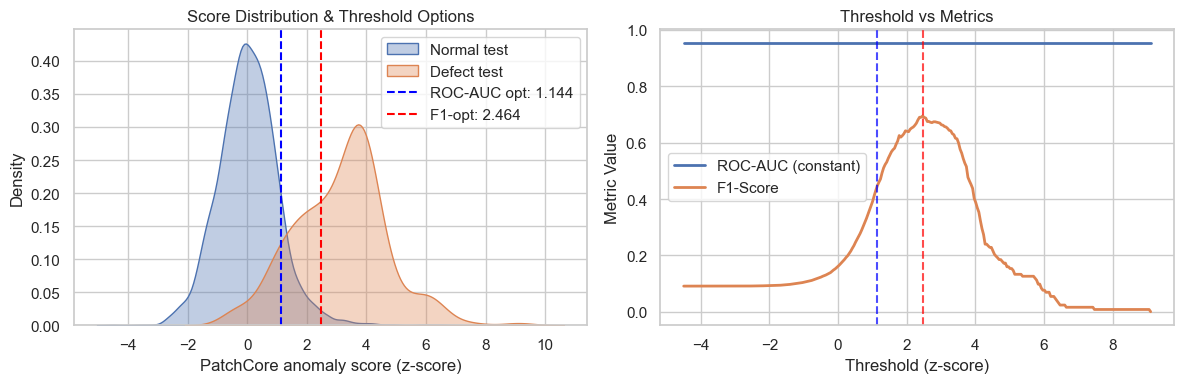

In [53]:
# Load saved scores
from sklearn.metrics import f1_score, roc_curve

with np.load(os.path.join(ARTIFACT_DIR, 'scores.npz')) as data:
    train_scores_z = data['train_scores_z']
    test_normal_scores_z = data['test_normal_scores_z']
    test_defect_scores_z = data['test_defect_scores_z']

# Prepare test data for threshold optimization
y_true = np.concatenate([
    np.zeros(len(test_normal_scores_z), dtype=int),
    np.ones(len(test_defect_scores_z), dtype=int),
])
scores = np.concatenate([test_normal_scores_z, test_defect_scores_z])

# Grid of candidate thresholds
candidate_thresholds = np.linspace(scores.min(), scores.max(), 300)

# === Approach 1: Maximize ROC-AUC ===
best_auc = 0
best_threshold_auc = None
for candidate in candidate_thresholds:
    y_pred = (scores > candidate).astype(int)
    auc = roc_auc_score(y_true, scores)
    # We use Youden's J statistic as proxy for optimal threshold on ROC curve
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    if (tp + fn) > 0 and (tn + fp) > 0:
        tpr = tp / (tp + fn)
        fpr = fp / (tn + fp)
        youdens_j = tpr - fpr
        if youdens_j > best_auc:
            best_auc = youdens_j
            best_threshold_auc = candidate

if best_threshold_auc is None:
    best_threshold_auc = candidate_thresholds[len(candidate_thresholds)//2]

y_pred_auc = (scores > best_threshold_auc).astype(int)
tp_auc = ((y_pred_auc == 1) & (y_true == 1)).sum()
fp_auc = ((y_pred_auc == 1) & (y_true == 0)).sum()
fn_auc = ((y_pred_auc == 0) & (y_true == 1)).sum()
tn_auc = ((y_pred_auc == 0) & (y_true == 0)).sum()
precision_auc = tp_auc / (tp_auc + fp_auc) if (tp_auc + fp_auc) > 0 else 0
recall_auc = tp_auc / (tp_auc + fn_auc) if (tp_auc + fn_auc) > 0 else 0
f1_auc = 2 * precision_auc * recall_auc / (precision_auc + recall_auc) if (precision_auc + recall_auc) > 0 else 0
roc_auc_val = roc_auc_score(y_true, scores)

# === Approach 2: Maximize F1-Score ===
best_f1 = 0
best_threshold_f1 = None
for candidate in candidate_thresholds:
    y_pred = (scores > candidate).astype(int)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_f1 = candidate

y_pred_f1 = (scores > best_threshold_f1).astype(int)
tp_f1 = ((y_pred_f1 == 1) & (y_true == 1)).sum()
fp_f1 = ((y_pred_f1 == 1) & (y_true == 0)).sum()
fn_f1 = ((y_pred_f1 == 0) & (y_true == 1)).sum()
tn_f1 = ((y_pred_f1 == 0) & (y_true == 0)).sum()
precision_f1 = tp_f1 / (tp_f1 + fp_f1) if (tp_f1 + fp_f1) > 0 else 0
recall_f1 = tp_f1 / (tp_f1 + fn_f1) if (tp_f1 + fn_f1) > 0 else 0
f1_f1 = 2 * precision_f1 * recall_f1 / (precision_f1 + recall_f1) if (precision_f1 + recall_f1) > 0 else 0

# === Comparison Table ===
print('\n' + '='*80)
print('THRESHOLD OPTIMIZATION COMPARISON')
print('='*80)
print(f'\n1. MAXIMIZE ROC-AUC (Youden\'s J):  threshold_z = {best_threshold_auc:.6f}')
print(f'   ROC-AUC: {roc_auc_val:.4f}')
print(f'   Precision: {precision_auc:.4f}, Recall: {recall_auc:.4f}, F1: {f1_auc:.4f}')
print(f'   TP: {int(tp_auc)}, FP: {int(fp_auc)}, FN: {int(fn_auc)}, TN: {int(tn_auc)}')

print(f'\n2. MAXIMIZE F1-SCORE:              threshold_z = {best_threshold_f1:.6f}')
print(f'   ROC-AUC: {roc_auc_val:.4f}')
print(f'   Precision: {precision_f1:.4f}, Recall: {recall_f1:.4f}, F1: {best_f1:.4f}')
print(f'   TP: {int(tp_f1)}, FP: {int(fp_f1)}, FN: {int(fn_f1)}, TN: {int(tn_f1)}')
print('\n' + '='*80)

# === Choose best approach (default: F1 for wafer defect detection) ===
threshold_z = best_threshold_f1  # F1 prioritizes both recall and precision
threshold_raw = train_score_mu + threshold_z * train_score_std
chosen_approach = 'F1-Score (Approach 2)'

print(f'\nCHOSEN: {chosen_approach}')
print(f'Z-threshold: {threshold_z:.6f}, Raw-threshold: {threshold_raw:.6f}')

# Visualization
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.kdeplot(test_normal_scores_z, label='Normal test', fill=True, alpha=0.35)
sns.kdeplot(test_defect_scores_z, label='Defect test', fill=True, alpha=0.35)
plt.axvline(best_threshold_auc, color='blue', linestyle='--', label=f'ROC-AUC opt: {best_threshold_auc:.3f}')
plt.axvline(best_threshold_f1, color='red', linestyle='--', label=f'F1-opt: {best_threshold_f1:.3f}')
plt.xlabel('PatchCore anomaly score (z-score)')
plt.ylabel('Density')
plt.title('Score Distribution & Threshold Options')
plt.legend()

plt.subplot(1, 2, 2)
metrics_roc = []
metrics_f1 = []
for cand in candidate_thresholds:
    y_p = (scores > cand).astype(int)
    metrics_roc.append(roc_auc_score(y_true, scores))
    metrics_f1.append(f1_score(y_true, y_p, zero_division=0))

plt.plot(candidate_thresholds, metrics_roc, label='ROC-AUC (constant)', linewidth=2)
plt.plot(candidate_thresholds, metrics_f1, label='F1-Score', linewidth=2)
plt.axvline(best_threshold_auc, color='blue', linestyle='--', alpha=0.7)
plt.axvline(best_threshold_f1, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Threshold (z-score)')
plt.ylabel('Metric Value')
plt.title('Threshold vs Metrics')
plt.legend()
plt.tight_layout()
plt.show()


EVALUATION WITH F1-SCORE THRESHOLD (CHOSEN)
ROC-AUC: 0.9543
Z-threshold: 2.463610 | Raw-threshold: 0.544521
              precision    recall  f1-score   support

      normal       0.98      0.98      0.98      5000
     anomaly       0.70      0.69      0.69       250

    accuracy                           0.97      5250
   macro avg       0.84      0.84      0.84      5250
weighted avg       0.97      0.97      0.97      5250


EVALUATION WITH ROC-AUC THRESHOLD (for comparison)
ROC-AUC: 0.9543
Z-threshold: 1.144451 | Raw-threshold: 0.493019
              precision    recall  f1-score   support

      normal       0.99      0.89      0.94      5000
     anomaly       0.30      0.90      0.45       250

    accuracy                           0.89      5250
   macro avg       0.65      0.90      0.69      5250
weighted avg       0.96      0.89      0.92      5250



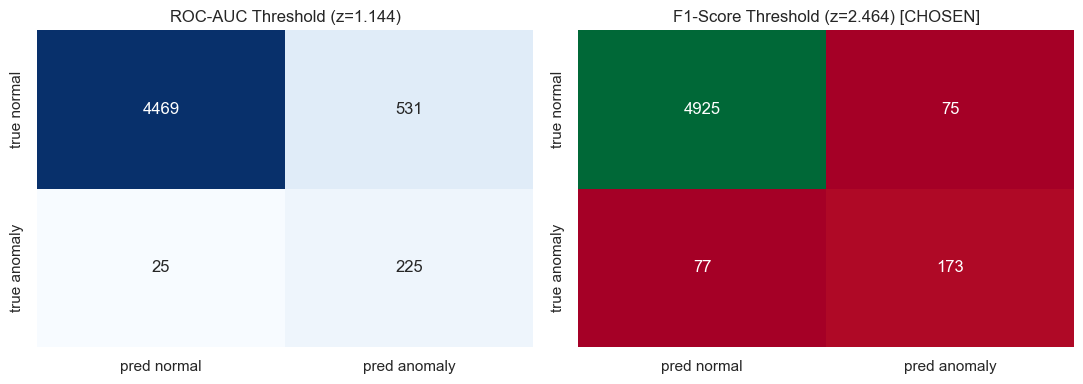

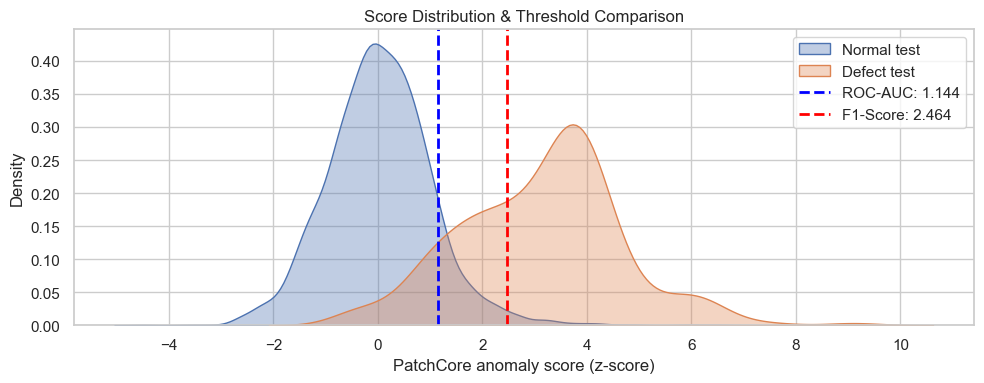

Saved model artifact to: ../artifacts/x64/patchcore_efficientnet_b1_50k\patchcore_efficientnet_b1_model.pt
Saved metrics to: ../artifacts/x64/patchcore_efficientnet_b1_50k\evaluation_metrics.json

Test defect samples: 250


In [56]:
# Final evaluation on test split (both thresholds for comparison)
y_true = np.concatenate([
    np.zeros(len(test_normal_scores_z), dtype=int),
    np.ones(len(test_defect_scores_z), dtype=int),
])
scores = np.concatenate([test_normal_scores_z, test_defect_scores_z])

roc_auc = float(roc_auc_score(y_true, scores))

# === Evaluation with F1-Score threshold (CHOSEN) ===
y_pred_f1 = (scores > best_threshold_f1).astype(int)
threshold_raw_f1 = train_score_mu + best_threshold_f1 * train_score_std
report_f1 = classification_report(y_true, y_pred_f1, target_names=['normal', 'anomaly'])
cm_f1 = confusion_matrix(y_true, y_pred_f1)

print('\n' + '='*80)
print('EVALUATION WITH F1-SCORE THRESHOLD (CHOSEN)')
print('='*80)
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Z-threshold: {best_threshold_f1:.6f} | Raw-threshold: {threshold_raw_f1:.6f}')
print(report_f1)

# === Evaluation with ROC-AUC threshold (for comparison) ===
y_pred_auc = (scores > best_threshold_auc).astype(int)
threshold_raw_auc = train_score_mu + best_threshold_auc * train_score_std
report_auc = classification_report(y_true, y_pred_auc, target_names=['normal', 'anomaly'])
cm_auc = confusion_matrix(y_true, y_pred_auc)

print('\n' + '='*80)
print('EVALUATION WITH ROC-AUC THRESHOLD (for comparison)')
print('='*80)
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Z-threshold: {best_threshold_auc:.6f} | Raw-threshold: {threshold_raw_auc:.6f}')
print(report_auc)
print('='*80)

# === Side-by-side confusion matrices ===
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm_auc, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title(f'ROC-AUC Threshold (z={best_threshold_auc:.3f})')

plt.subplot(1, 2, 2)
sns.heatmap(cm_f1, annot=True, fmt='d', cmap='RdYlGn', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title(f'F1-Score Threshold (z={best_threshold_f1:.3f}) [CHOSEN]')
plt.tight_layout()
plt.show()

# === Score distributions with both thresholds ===
plt.figure(figsize=(10, 4))
sns.kdeplot(test_normal_scores_z, label='Normal test', fill=True, alpha=0.35)
sns.kdeplot(test_defect_scores_z, label='Defect test', fill=True, alpha=0.35)
plt.axvline(best_threshold_auc, color='blue', linestyle='--', linewidth=2, label=f'ROC-AUC: {best_threshold_auc:.3f}')
plt.axvline(best_threshold_f1, color='red', linestyle='--', linewidth=2, label=f'F1-Score: {best_threshold_f1:.3f}')
plt.xlabel('PatchCore anomaly score (z-score)')
plt.ylabel('Density')
plt.title('Score Distribution & Threshold Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Use F1 threshold as default (can switch to best_threshold_auc if needed)
threshold_z = best_threshold_f1
threshold_raw = threshold_raw_f1
cm = cm_f1

# Store model artifacts
artifact = {
    'extractor_state_dict': extractor.state_dict(),
    'threshold_z': float(threshold_z),
    'threshold_raw': float(threshold_raw),
    'threshold_z_auc': float(best_threshold_auc),
    'threshold_raw_auc': float(threshold_raw_auc),
    'train_score_mu': float(train_score_mu),
    'train_score_std': float(train_score_std),
    'config': {
        'image_size': IMAGE_SIZE,
        'train_normal_n': TRAIN_NORMAL_N,
        'test_normal_n': TEST_NORMAL_N,
        'test_defect_n': TEST_DEFECT_N,
        'score_chunk': SCORE_CHUNK,
        'patchcore_nn_k': PATCHCORE_NN_K,
        'patchcore_topk_patch_ratio': TOPK_PATCH_RATIO,
        'effnet_mid_feature_idx': EFFNET_MID_FEATURE_IDX,
        'effnet_deep_feature_idx': EFFNET_DEEP_FEATURE_IDX,
        'patch_embed_dim': PATCH_EMBED_DIM,
        'threshold_train_percentile': THRESHOLD_TRAIN_PERCENTILE,
    },
}
torch.save(artifact, MODEL_EXPORT_PATH)

metrics = {
    'roc_auc': roc_auc,
    'threshold_z': float(threshold_z),
    'threshold_raw': float(threshold_raw),
    'threshold_z_auc': float(best_threshold_auc),
    'threshold_raw_auc': float(threshold_raw_auc),
    'train_score_mu': float(train_score_mu),
    'train_score_std': float(train_score_std),
    'confusion_matrix_f1': cm_f1.tolist(),
    'confusion_matrix_auc': cm_auc.tolist(),
    'n_test_normal': int(len(test_normal_scores_z)),
    'n_test_defect': int(len(test_defect_scores_z)),
}
pd.Series(metrics).to_json(METRICS_EXPORT_PATH, indent=2)

print('Saved model artifact to:', MODEL_EXPORT_PATH)
print('Saved metrics to:', METRICS_EXPORT_PATH)
print(f'\nTest defect samples: {TEST_DEFECT_N}')

In [ ]:
# Per-defect-class breakdown (both thresholds)
tmp = test_defect_df.copy()
tmp['score'] = test_defect_scores_z
tmp['detected_auc'] = (test_defect_scores_z > best_threshold_auc).astype(int)
tmp['detected_f1'] = (test_defect_scores_z > best_threshold_f1).astype(int)

print('\n' + '='*80)
print('PER-DEFECT-CLASS RECALL (ROC-AUC Threshold)')
print('='*80)
recall_auc_table = tmp.groupby('failure_label').agg(
    count=('detected_auc', 'count'),
    detected=('detected_auc', 'sum'),
    recall=('detected_auc', 'mean'),
    mean_score=('score', 'mean'),
).round(3).sort_values('recall')
display(recall_auc_table)

print('\n' + '='*80)
print('PER-DEFECT-CLASS RECALL (F1-Score Threshold - CHOSEN)')
print('='*80)
recall_f1_table = tmp.groupby('failure_label').agg(
    count=('detected_f1', 'count'),
    detected=('detected_f1', 'sum'),
    recall=('detected_f1', 'mean'),
    mean_score=('score', 'mean'),
).round(3).sort_values('recall')
display(recall_f1_table)
print('='*80)


Per-defect-class recall:


,count,detected,recall,mean_score
failure_label,,,,
Scratch,11,1,0.091,1.527
Center,34,8,0.235,2.069
Loc,41,10,0.244,1.981
Edge-Loc,44,22,0.500,2.846
Random,13,12,0.923,5.179
Edge-Ring,102,95,0.931,3.861
Donut,2,2,1.000,4.544
Near-full,3,3,1.000,5.842


In [ ]:
# Clear memory after run
vars_to_clear = [
    'train_dataset', 'test_normal_dataset', 'test_defect_dataset',
    'sample_x', 'sample_y',
    'sampled_patches', 'memory_bank', 'memory_bank_t',
    'train_scores', 'test_normal_scores', 'test_defect_scores',
    'train_scores_z', 'test_normal_scores_z', 'test_defect_scores_z',
    'scores', 'y_true', 'y_pred_auc', 'y_pred_f1',
    'candidate_thresholds', 'recall_auc_table', 'recall_f1_table', 'tmp',
    'train_loader', 'test_normal_loader', 'test_defect_loader',
]
for name in vars_to_clear:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print('Memory cleared (Python GC + CUDA cache).')
print('\n' + '='*80)
print('FINAL MODEL CONFIGURATION')
print('='*80)
print(f'Chosen Threshold: F1-Score (z={best_threshold_f1:.6f})')
print(f'Alternative: ROC-AUC (z={best_threshold_auc:.6f})')
print(f'ROC-AUC Score: {roc_auc:.4f}')
print('='*80)

Memory cleared (Python GC + CUDA cache).


## Notes

- Memory bank is capped by `MEMORY_BANK_MAX_PATCHES` to control RAM/VRAM.
- If GPU memory is tight, reduce `BATCH_SIZE` and/or `SCORE_CHUNK`.
- This version uses a fixed threshold from train-normal scores via `THRESHOLD_TRAIN_PERCENTILE` (no tune split).